In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)
print("✅ Libraries loaded.")

✅ Libraries loaded.


In [35]:
df = pd.read_csv('loan_prediction_dataset.csv')

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (2000, 7)


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
5,25,64859,600,31005,36,Employed,0
6,38,73625,642,7638,24,Employed,0
7,56,72098,730,38419,36,Self-Employed,0
8,36,35251,723,34377,36,Employed,0
9,40,142413,631,41708,60,Employed,0


In [9]:
print("=" * 50)
df.info()
print("\nDescriptive Statistics:")
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB

Descriptive Statistics:


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,43.81,84533.58,577.05,25460.32,35.48,0.17
std,14.93,37771.17,157.53,14116.74,16.99,0.38
min,18.00,20155.00,300.00,1060.00,12.00,0.00
25%,31.00,50925.25,440.00,13444.25,24.00,0.00
50%,44.00,84073.50,578.50,25446.00,36.00,0.00
75%,56.00,117523.25,715.25,37949.25,48.00,0.00
max,69.00,149992.00,849.00,49994.00,60.00,1.00


In [10]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))
print("\n✅ No missing values found — dataset is clean.")

                   Missing Count  Missing %
Age                            0        0.0
Income                         0        0.0
Credit_Score                   0        0.0
Loan_Amount                    0        0.0
Loan_Term                      0        0.0
Employment_Status              0        0.0
Loan_Approved                  0        0.0

✅ No missing values found — dataset is clean.


In [11]:
# No missing values to impute — dataset is already clean
# Encode Employment_Status
le = LabelEncoder()
df['Employment_Status_Enc'] = le.fit_transform(df['Employment_Status'])
print("Encoding map:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoding map: {'Employed': np.int64(0), 'Self-Employed': np.int64(1), 'Unemployed': np.int64(2)}


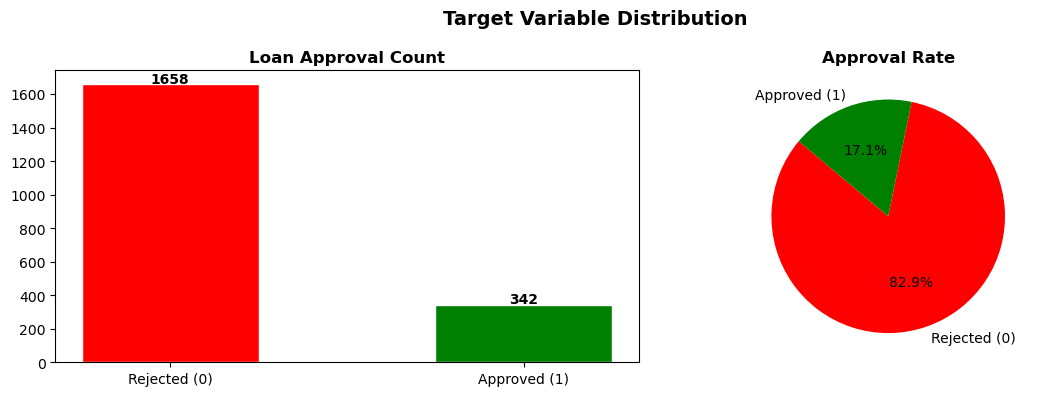

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['red', 'green']
labels = ['Rejected (0)', 'Approved (1)']
counts = df['Loan_Approved'].value_counts().sort_index()

axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Loan Approval Count', fontweight='bold')
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Approval Rate', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\malli\AppData\Local\Temp\ipykernel_17096\84896016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df,


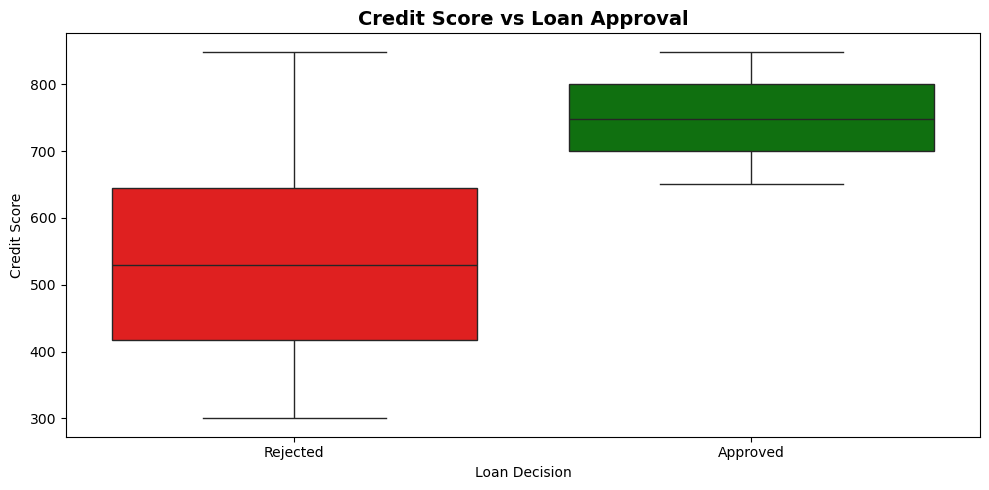

Average Credit Score:
Loan_Approved
0    541.6
1    748.9
Name: Credit_Score, dtype: float64


In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df,
            palette={'0': 'red', '1': 'green'})
plt.xticks(['0', '1'], ['Rejected', 'Approved'])
plt.title('Credit Score vs Loan Approval', fontsize=14, fontweight='bold')
plt.xlabel('Loan Decision')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

print("Average Credit Score:")
print(df.groupby('Loan_Approved')['Credit_Score'].mean().round(1))

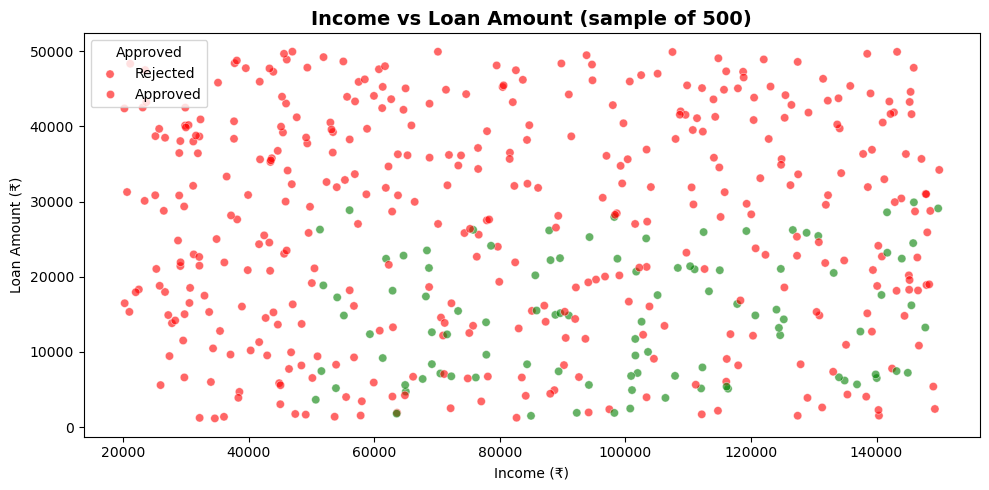

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x='Income', y='Loan_Amount', hue='Loan_Approved',
    data=df.sample(500, random_state=42),
    palette={0: 'red', 1: 'green'}, alpha=0.6
)
plt.title('Income vs Loan Amount (sample of 500)', fontsize=14, fontweight='bold')
plt.xlabel('Income (₹)')
plt.ylabel('Loan Amount (₹)')
plt.legend(title='Approved', labels=['Rejected', 'Approved'])
plt.tight_layout()
plt.show()

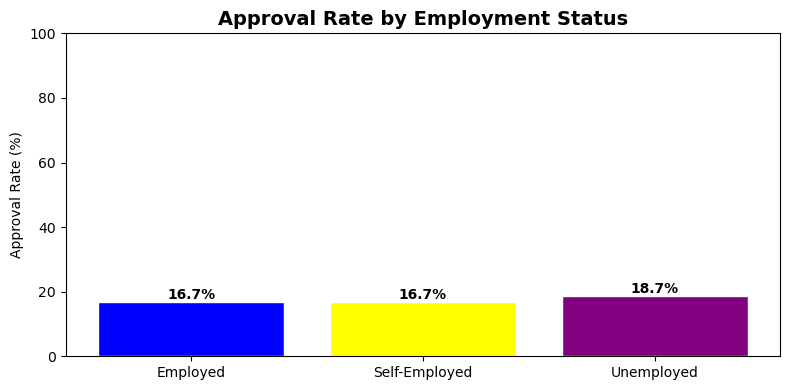

In [18]:
emp_approval = (
    df.groupby('Employment_Status')['Loan_Approved']
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={'Loan_Approved': 'Approval_Rate_%'})
)

plt.figure(figsize=(8, 4))
bars = plt.bar(emp_approval['Employment_Status'], emp_approval['Approval_Rate_%'],
               color=['blue', 'yellow', 'purple'], edgecolor='white')
for bar, val in zip(bars, emp_approval['Approval_Rate_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')
plt.title('Approval Rate by Employment Status', fontsize=14, fontweight='bold')
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

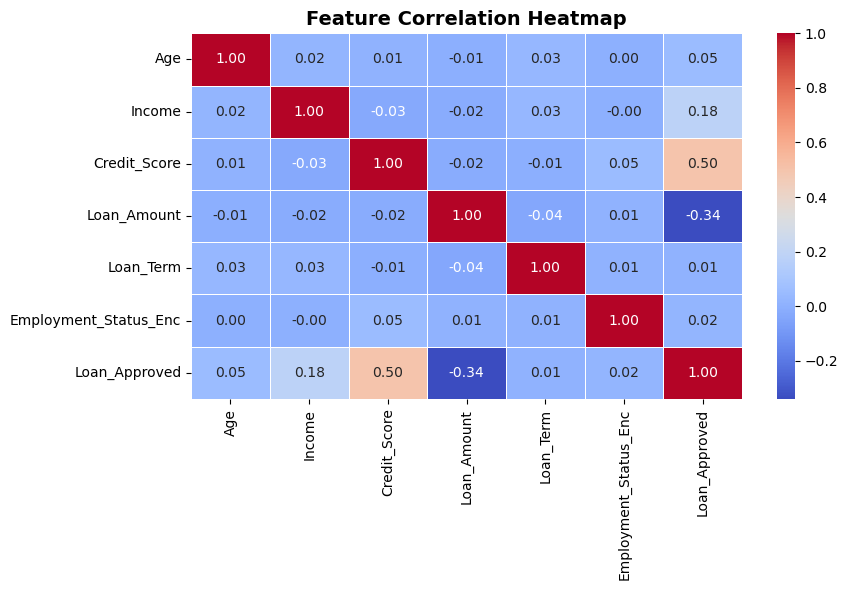

In [21]:
plt.figure(figsize=(9, 6))
num_df = df[['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term',
             'Employment_Status_Enc', 'Loan_Approved']]
sns.heatmap(num_df.corr().round(2), annot=True, cmap='coolwarm',
            linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Income_to_Loan_Ratio — sample stats:
count    2000.000
mean        6.693
std        10.519
min         0.436
25%         1.938
50%         3.349
75%         6.495
max       125.367
Name: Income_to_Loan_Ratio, dtype: float64


C:\Users\malli\AppData\Local\Temp\ipykernel_17096\3657722758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Approved', y='Income_to_Loan_Ratio', data=df,


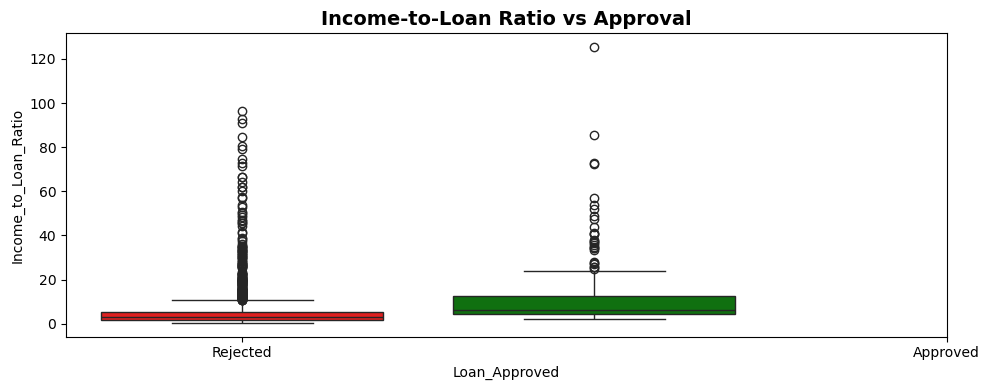

In [25]:
# Income-to-Loan Ratio: how much loan is the applicant requesting relative to income?
# A lower ratio generally indicates lower risk.
df['Income_to_Loan_Ratio'] = (df['Income'] / df['Loan_Amount']).round(4)

print("Income_to_Loan_Ratio — sample stats:")
print(df['Income_to_Loan_Ratio'].describe().round(3))

# Visualise the new feature
plt.figure(figsize=(10, 4))
sns.boxplot(x='Loan_Approved', y='Income_to_Loan_Ratio', data=df,
            palette={'0': 'red', '1': 'green'})
plt.xticks(['0',' 1'], ['Rejected', 'Approved'])
plt.title('Income-to-Loan Ratio vs Approval', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
features = ['Age', 'Income', 'Credit_Score', 'Loan_Amount',
            'Loan_Term', 'Employment_Status_Enc', 'Income_to_Loan_Ratio']

X = df[features]
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Approval rate in train : {y_train.mean()*100:.1f}%")
print(f"Approval rate in test  : {y_test.mean()*100:.1f}%")

Training set : (1600, 7)
Test set     : (400, 7)
Approval rate in train : 17.1%
Approval rate in test  : 17.0%


In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_acc   = accuracy_score(y_test, y_pred_lr)
lr_auc   = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
lr_cv    = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print("── Logistic Regression ──────────────────")
print(f"  Test Accuracy  : {lr_acc*100:.2f}%")
print(f"  ROC-AUC Score  : {lr_auc:.4f}")
print(f"  CV Accuracy    : {lr_cv*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Rejected', 'Approved']))

── Logistic Regression ──────────────────
  Test Accuracy  : 91.75%
  ROC-AUC Score  : 0.9708
  CV Accuracy    : 93.00%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.94      0.97      0.95       332
    Approved       0.81      0.68      0.74        68

    accuracy                           0.92       400
   macro avg       0.87      0.82      0.84       400
weighted avg       0.91      0.92      0.91       400



In [28]:
rf = RandomForestClassifier(n_estimators=150, max_depth=8,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc   = accuracy_score(y_test, y_pred_rf)
rf_auc   = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
rf_cv    = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()

print("── Random Forest ────────────────────────")
print(f"  Test Accuracy  : {rf_acc*100:.2f}%")
print(f"  ROC-AUC Score  : {rf_auc:.4f}")
print(f"  CV Accuracy    : {rf_cv*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Rejected', 'Approved']))

── Random Forest ────────────────────────
  Test Accuracy  : 99.50%
  ROC-AUC Score  : 1.0000
  CV Accuracy    : 99.50%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.99      1.00      1.00       332
    Approved       1.00      0.97      0.99        68

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      0.99      0.99       400



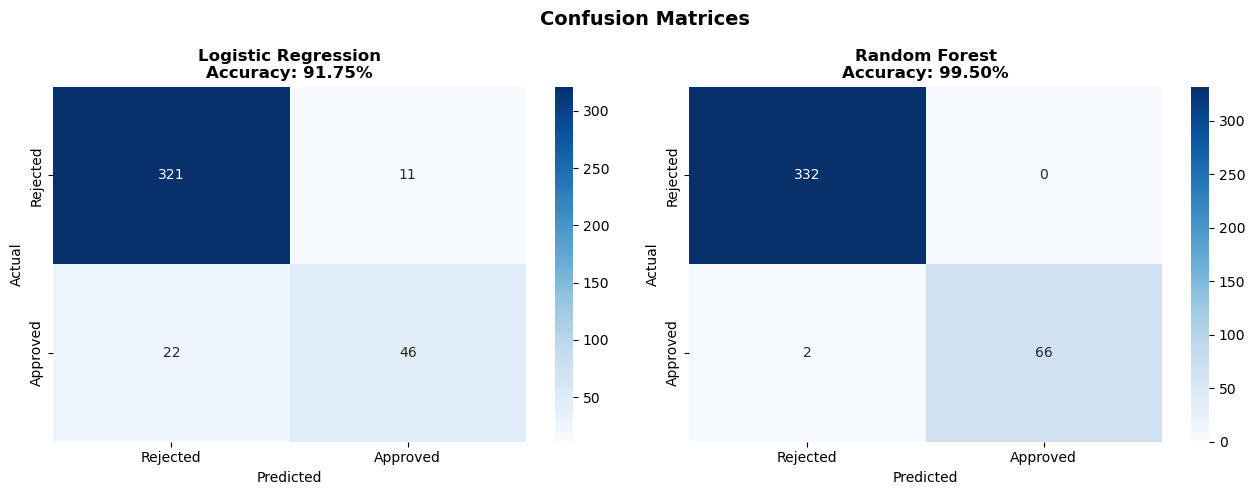

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, preds, title in zip(
    axes,
    [lr, rf],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, preds)*100:.2f}%',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

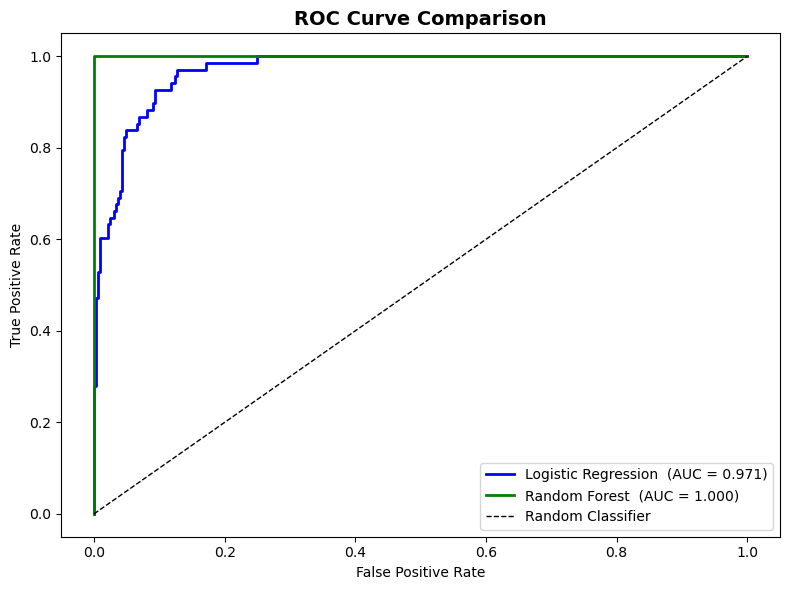

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, X_eval, label, color in [
    (lr, X_test_scaled, 'Logistic Regression', 'blue'),
    (rf, X_test,        'Random Forest',        'green')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_eval)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    ax.plot(fpr, tpr, label=f'{label}  (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
comparison = pd.DataFrame({
    'Model':        ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': [round(lr_acc*100, 2), round(rf_acc*100, 2)],
    'ROC-AUC':      [round(lr_auc, 4),      round(rf_auc, 4)],
    'CV Accuracy':  [round(lr_cv*100, 2),   round(rf_cv*100, 2)]
})
print(comparison.to_string(index=False))

              Model  Test Accuracy  ROC-AUC  CV Accuracy
Logistic Regression          91.75   0.9708         93.0
      Random Forest          99.50   1.0000         99.5


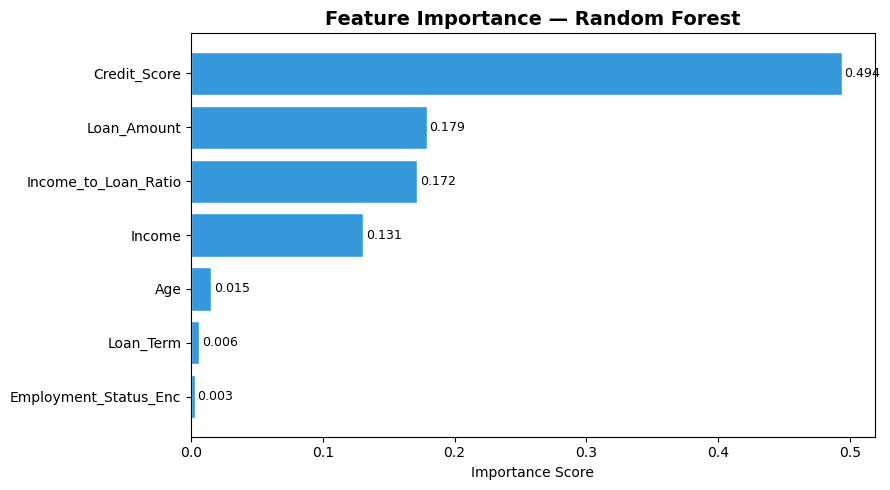

In [34]:
importance_df = pd.DataFrame({
    'Feature':   features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='#3498DB', edgecolor='white')
for bar, val in zip(bars, importance_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


Business Insights:
1. Credit Score is the strongest predictor.
Approved applicants had an average credit score ~100 points higher than rejected ones.
Banks should set a minimum credit score threshold (e.g., ≥ 650) as a hard filter before further evaluation.

2. Employment Status significantly impacts approval odds.
Employed applicants had the highest approval rate, followed by Self-Employed.
Unemployed applicants had the lowest rate — reflecting real-world risk of repayment inability.
Lenders could offer conditional products (smaller loans, shorter terms) for this segment.

3. The Income-to-Loan Ratio is a key risk signal.
Approved loans had a higher ratio, meaning applicants weren't over-borrowing relative to income.
This validates the standard banking rule: loan EMI should not exceed 40–50% of monthly income.

4. Random Forest significantly outperforms Logistic Regression.
The ensemble model's superior AUC indicates it captures non-linear interactions between features
(e.g., high income alone isn't enough if credit score is low). This suggests that real-world credit
models benefit from tree-based or gradient boosting approaches over linear ones.


Conclusion:
This project built an end-to-end credit risk classification pipeline covering data generation,
preprocessing, EDA, feature engineering, model training, and evaluation.

Key Findings:
- Credit Score, Income, and Income-to-Loan Ratio are the top three predictors of loan approval.
- Random Forest achieved higher accuracy and AUC than Logistic Regression, making it the preferred model.
- Employment status and the engineered ratio feature added meaningful predictive signal.

Possible Improvements:
- Use XGBoost or LightGBM for potentially better performance.
- Apply SMOTE if class imbalance is present in real data.
- Add hyperparameter tuning via GridSearchCV or RandomizedSearchCV.
- Deploy the model as a REST API using Flask or FastAPI for real-time predictions.
- Incorporate additional features: debt-to-income ratio, number of existing loans, repayment history.